In [2]:
import pandas as pd

students = pd.read_csv("StudentsPerformance 1.csv")
students.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
students.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [4]:
students.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [5]:
numeric_info = students.select_dtypes(include='number')
corr = numeric_info.corr()
corr

,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


In [6]:
students.groupby('gender')['math score'].mean()

#the average math score is higher for male students compared to female students 
#(68.728216 > 63.633205)

gender
female    63.633205
male      68.728216
Name: math score, dtype: float64

In [ ]:
corr_rw = students['reading score'].corr(students['writing score'])
print("corr between reading and writing:", corr_rw)

#Strong positive correlation (0.95).
#Students who do well in reading almost always do well in writing

corr between reading and writing: 0.9545980771462478


In [11]:
scores = ['math score', 'reading score', 'writing score']
students.groupby('test preparation course')[scores].mean()

#Students who completed the test preparation course scored higher on average in all 
#subjects compared to those who did not complete it.
#the test preparation course has a positive impact on student performance, especially 
#reading and writing.


,math score,reading score,writing score
test preparation course,,,
completed,69.695531,73.893855,74.418994
none,64.077882,66.534268,64.504673


In [ ]:
students.groupby('parental level of education')[scores].mean()

#Students whose parents have a master's or bachelor's degree achieve the highest
#average scores across all subjects, especially in reading and writing.
#Lower average scores are observed among students whose parents have only
#high school or some high school education.


,math score,reading score,writing score
parental level of education,,,
associate's degree,67.882883,70.927928,69.896396
bachelor's degree,69.389831,73.000000,73.381356
high school,62.137755,64.704082,62.448980
master's degree,69.745763,75.372881,75.677966
some college,67.128319,69.460177,68.840708
some high school,63.497207,66.938547,64.888268


In [13]:
students.groupby('lunch')[scores].mean()

#The table shows that students receiving standard lunch consistently outperform 
#students with free/reduced lunch across all subject scores.

,math score,reading score,writing score
lunch,,,
free/reduced,58.921127,64.653521,63.022535
standard,70.034109,71.654264,70.823256


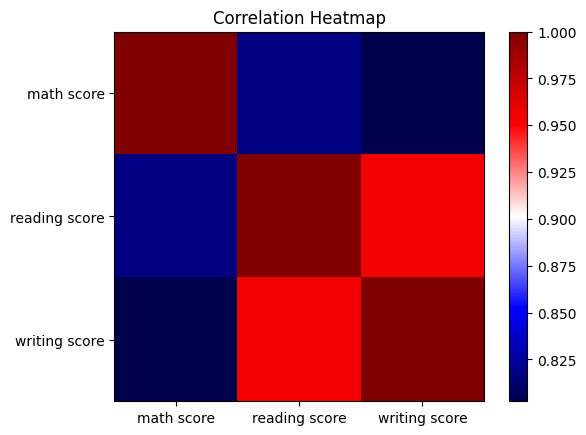

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

students = pd.read_csv("StudentsPerformance 1.csv")
numeric_info = students.select_dtypes(include='number')
corr = numeric_info.corr()

plt.imshow(corr, cmap='seismic', interpolation='none')
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns)
plt.yticks(range(len(corr)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()

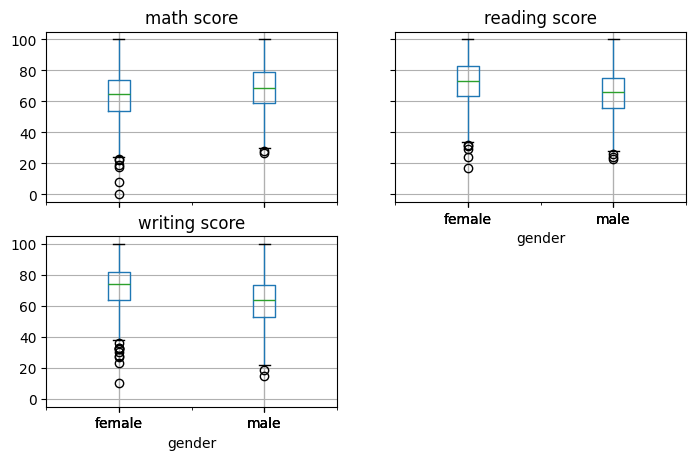

In [4]:
import matplotlib.pyplot as plt

students.boxplot(
    column=['math score', 'reading score', 'writing score'],
    by='gender',
    figsize=(8, 5)
)

plt.title('Score distribution by gender')
plt.suptitle('')
plt.xlabel('Gender')
plt.ylabel('Score')
plt.show()




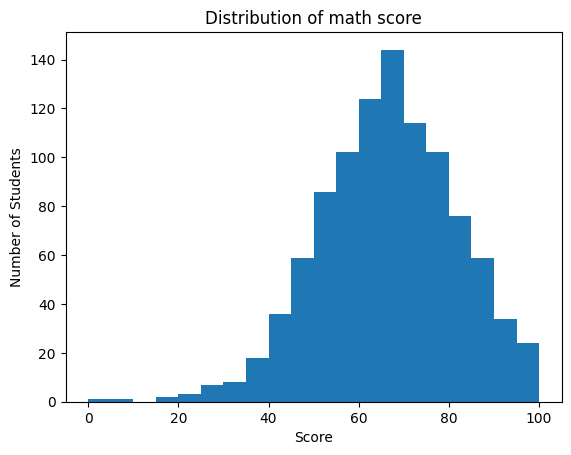

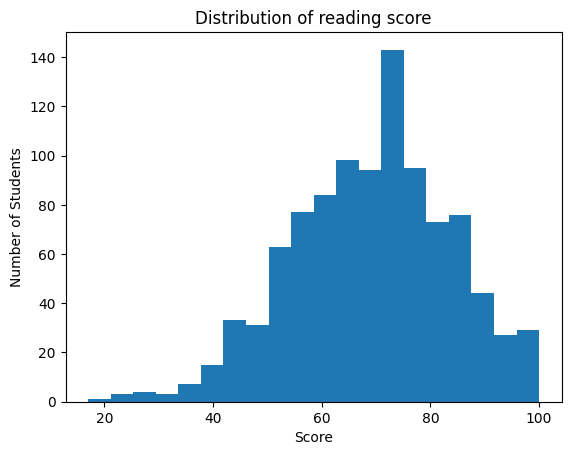

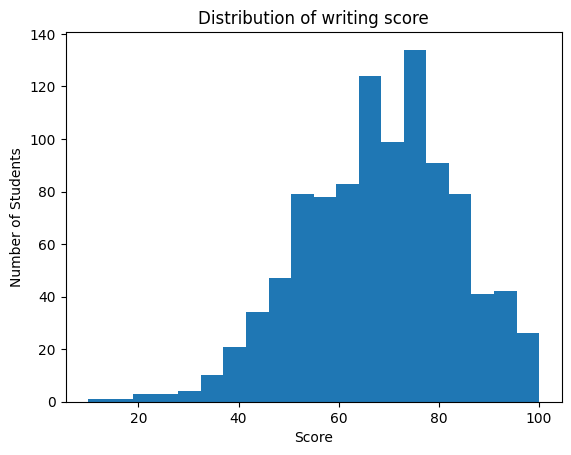

In [15]:
subjects = ['math score', 'reading score', 'writing score']

for subject in subjects:
    plt.hist(students[subject], bins=20)
    plt.title(f'Distribution of {subject}')
    plt.xlabel('Score')
    plt.ylabel('Number of Students')
    plt.show()


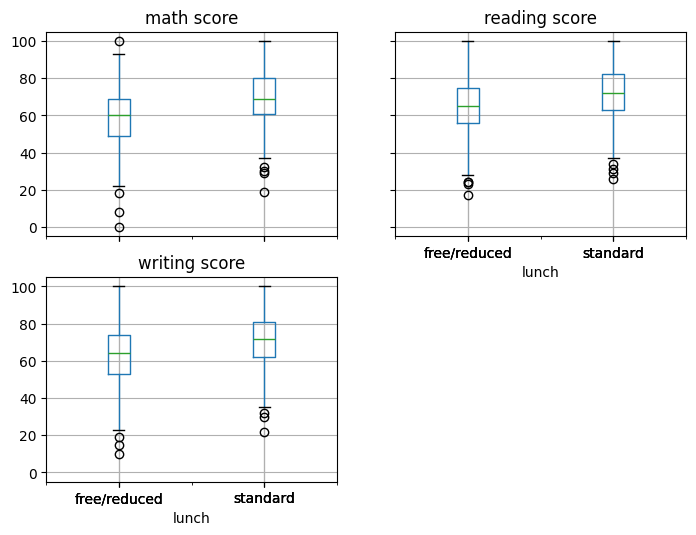

In [8]:
import matplotlib.pyplot as plt

students.boxplot(
    column=['math score', 'reading score', 'writing score'],
    by='lunch',
    figsize=(8, 6)
)

plt.title('Score Distribution by Lunch Type')
plt.suptitle('')
plt.xlabel('Lunch Type')
plt.ylabel('Score')
plt.show()


In [ ]:
students.groupby('gender')[['math score', 'reading score', 'writing score']].mean()


,math score,reading score,writing score
gender,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203


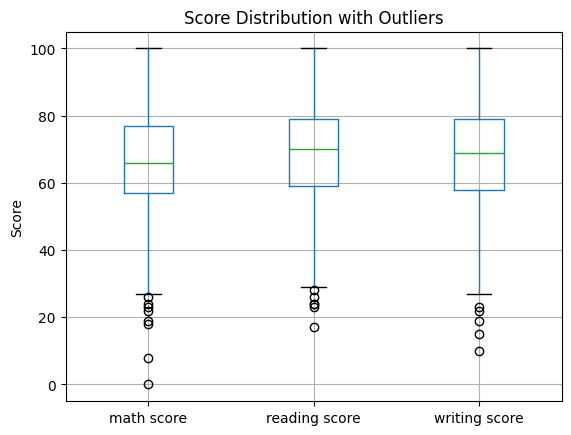

In [6]:
students[['math score', 'reading score', 'writing score']].boxplot()
plt.title('Score Distribution with Outliers')
plt.ylabel('Score')
plt.show()
